# Практична робота №2.
# Побудова та оцiнювання якостi моделей класифiкацiї та регресiї засобами бiблiотеки Scikit-Learn Python
Варіант 25 \
Виконали студенти групи КА-35 Бернацький Артем, Бубало Анна, Іванкевич Богдан, Шальман Тимофій

# Dataset A

In [38]:
from sklearn.datasets import make_blobs
import numpy as np


X, y_true = make_blobs (
    n_samples=400,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

### Візуалізація датасету

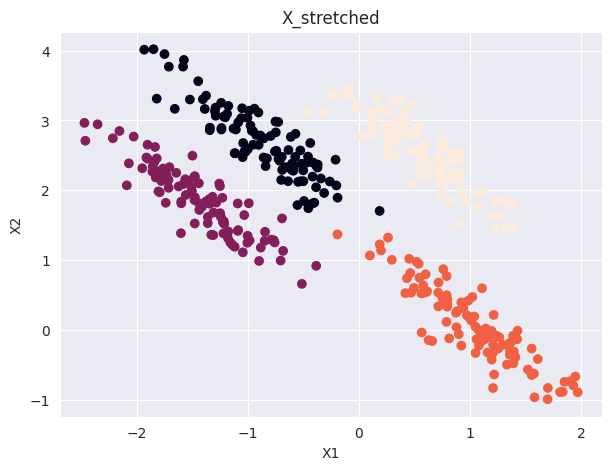

In [39]:
import matplotlib.pyplot as plt


def show_scatter(X, y, title=None):
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y)
    if title:
        plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

show_scatter(X_stretched, y_true, title="X_stretched")

## Реалізація функцій для виводу метрик та візуалізації роботи моделі

In [40]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, classifier_name, resolution=0.02):
    """
    Візуалізація меж класифікації.
    Параметри:
        model      - навчена модель
        X_test     - тестові ознаки
        y_true     - справжні мітки
        model_name - назва моделі,
                     яка відображається в заголовку графіка
        resolution - крок сітки для побудови областей
    """

    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Створюємо сітку точок для візуалізації меж
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Створюємо сітку координат
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Прогноз для кожної точки сітки
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    # Малюємо графік
    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title(classifier_name)
    plt.xlabel("X1")
    plt.ylabel("X2")
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black"
        )

    plt.show()

In [41]:
import warnings
import seaborn as sns
import sklearn.metrics as metrics


def get_classifier_score(X, y, classifier):
    warnings.filterwarnings("ignore")

    y_pred = classifier.predict(X)

    class_names = [f"Class {i}" for i in np.unique(y).astype(int)]

    # Classification report
    print(metrics.classification_report(y, y_pred, target_names=class_names))

    # Confusion matrix
    conf_matrix = metrics.confusion_matrix(y, y_pred)
    plt.figure(figsize =(6, 6))
    sns.heatmap(
        data=conf_matrix,
        xticklabels=class_names,
        yticklabels=class_names,
        annot=True,
        fmt="d",
        square=True,
        cmap="coolwarm",
        vmax=20
    )
    plt.ylabel("True class")
    plt.xlabel("Predicted class")
    plt.show()

    warnings.filterwarnings("always")

In [42]:
from sklearn.preprocessing import label_binarize


def plot_roc_auc(X, y, classifier):
    """
    Побудова ROC–AUC кривої для бінарної або мультикласової класифікації.
    Параметри:
        model   - навчена модель
        X_test  - тестові ознаки
        y_true  - справжні мітки
    """

    # Отримуємо ймовірності або передбачення
    y_score = classifier.predict_proba(X)
    classes = np.unique(y)
    n_classes = len(classes)

    # Якщо бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        fpr, tpr, _ = metrics.roc_curve(y, y_score)
        roc_auc = metrics.auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve")
        plt.legend()
        plt.show()
        print(f"ROC–AUC = {roc_auc:.3f}")

    # Якщо мультикласова класифікація
    else:
        y_bin = label_binarize(y, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            fpr[i], tpr[i], _ = metrics.roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc[i] = metrics.auc(fpr[i], tpr[i])

        # Усереднений (macro) ROC–AUC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in fpr]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in fpr:
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(fpr)
        macro_auc = metrics.auc(all_fpr, mean_tpr)

        plt.figure()
        for i in fpr:
            plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve")
        plt.legend()
        plt.show()

        print(f"Macro-average ROC-AUC = {macro_auc:.3f}")

In [43]:
def plot_pr_curve(X, y, classifier):
    """
    Побудова Precision-Recall кривої для бінарної або мультикласової класифікації.
    Параметри:
        model   - навчена модель
        X_test  - тестові ознаки
        y_true  - справжні мітки
    """

    y_score = classifier.predict_proba(X)
    classes = np.unique(y)
    n_classes = len(classes)

    # Бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        precision, recall, _ = metrics.precision_recall_curve(y, y_score)
        ap = metrics.average_precision_score(y, y_score)

        plt.figure()
        plt.plot(recall, precision, label=f"AP = {ap:.3f}")
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
        print(f"Average Precision (AUC PR) = {ap:.3f}")

    # Мультикласова класифікація
    else:
        y_bin = label_binarize(y, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        precision, recall, ap = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            precision[i], recall[i], _ = metrics.precision_recall_curve(y_bin[:, i], y_score[:, i])
            ap[i] = metrics.average_precision_score(y_bin[:, i], y_score[:, i])

        # Усереднення
        all_recall = np.unique(np.concatenate([recall[i] for i in recall]))
        mean_precision = np.zeros_like(all_recall)
        for i in recall:
            mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
        mean_precision /= len(recall)
        macro_ap = np.mean(list(ap.values()))

        plt.figure()
        for i in precision:
            plt.plot(recall[i], precision[i], label=f"Class {classes[i]} (AP = {ap[i]:.3f})")
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

        print(f"Macro-average AUC Precision–Recall = {macro_ap:.3f}")

### Розділ вибірки на навчальну та тестову

In [44]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_stretched, y_true, test_size=0.25, random_state=0
)

## Ініціалізація та навчання моделі naive_bayes.GaussianNB

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


gnb = GaussianNB()
gnb.fit(X_train, y_train)

accuracy_score(y_test, gnb.predict(X_test))

0.97

### Використання GridSearch для підбору гіперпараметрів для GaussianNB

In [46]:
from sklearn.model_selection import GridSearchCV


param_grid_gnb = {
    "var_smoothing": [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

grid_gnb = GridSearchCV(gnb, param_grid_gnb, cv=5)
grid_gnb.fit(X_train, y_train)

print(f"Best params:    {grid_gnb.best_params_}")
print(f"Train accuracy: {grid_gnb.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_gnb.best_estimator_.predict(X_test))}")

Best params:    {'var_smoothing': 1e-10}
Train accuracy: 0.9533333333333334
Test accuracy:  0.97


### Перевірка роботи GaussianNB на тренувальних вибірках різного розміру

In [47]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, test_size=1-size, random_state=0
    )
    gnb.fit(X_sub, y_sub)

    acc = accuracy_score(y_test, gnb.predict(X_test))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 30 Accuracy = 0.93
Train size = 90 Accuracy = 0.97
Train size = 150 Accuracy = 0.96
Train size = 209 Accuracy = 0.97
Train size = 270 Accuracy = 0.97


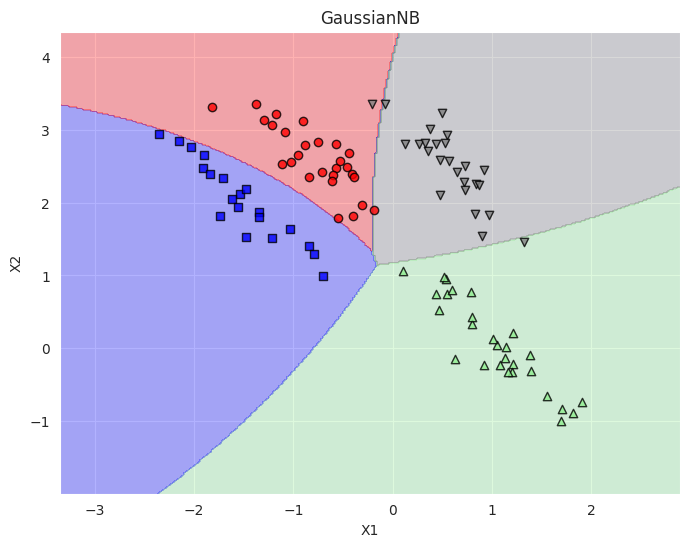

In [48]:
gnb = GaussianNB(var_smoothing=1e-10)
gnb.fit(X_train, y_train)

plot_decision_regions(X_test, y_test, gnb, classifier_name="GaussianNB")

### Метрики моделі naive_bayes.GaussianNB

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.95      0.97      0.96        73
     Class 1       1.00      1.00      1.00        80
     Class 2       0.97      0.96      0.97        72
     Class 3       0.93      0.92      0.93        75

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



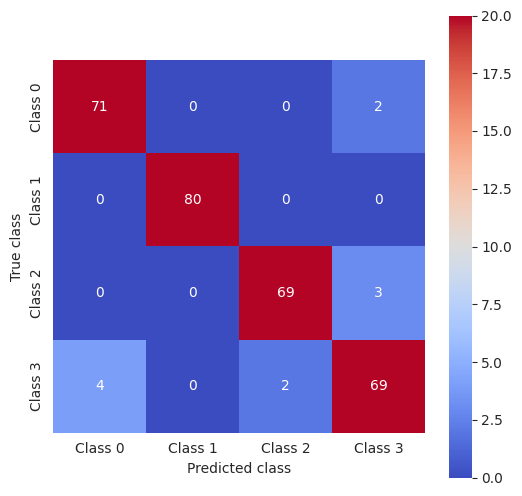

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.96      0.96      0.96        27
     Class 1       1.00      1.00      1.00        20
     Class 2       0.97      1.00      0.98        28
     Class 3       0.96      0.92      0.94        25

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



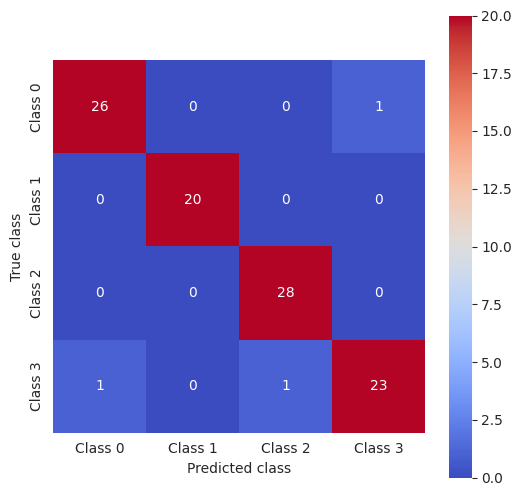

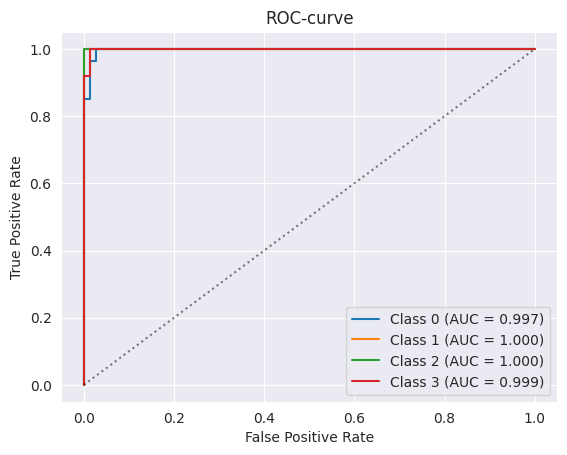

Macro-average ROC-AUC = 0.999


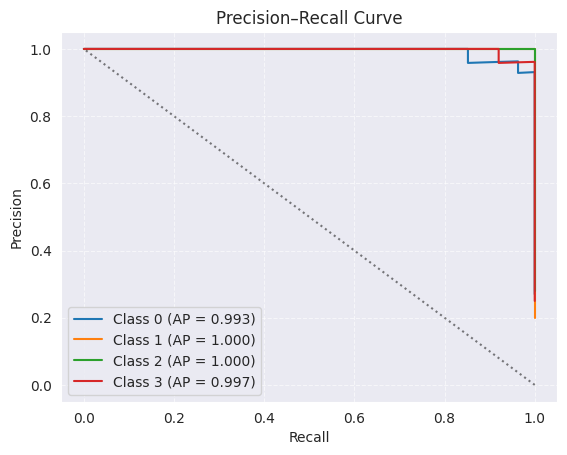

Macro-average AUC Precision–Recall = 0.998


In [49]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, gnb)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, gnb)
plot_roc_auc(X_test, y_test, gnb)
plot_pr_curve(X_test, y_test, gnb)

In [50]:
# Overfitting
train_acc = accuracy_score(y_train, gnb.predict(X_train))
test_acc = accuracy_score(y_test, gnb.predict(X_test))
print(train_acc - test_acc)

-0.006666666666666599


Отримані результати свідчать про **високу ефективність** класифікаційної моделі. \
Загальна точність становить **97%**, що підтверджується високими значеннями precision, recall та f1-score для всіх класів.

Confusion matrix показує майже ідеальну діагональ, а ROC-криві для всіх класів мають AUC понад **0.98**, \
що свідчить про чудову роздільну здатність моделі.

Різниці між оцінками train і test майже не має, \
отже, модель **не перенавчена**.

In [51]:
gnb.predict_proba(X_test)

array([[8.58239200e-05, 1.78653226e-07, 2.41937586e-02, 9.75720239e-01],
       [2.05306919e-01, 7.94693034e-01, 1.03548855e-13, 4.73482500e-08],
       [3.81825682e-02, 9.61817377e-01, 2.87245307e-11, 5.48542866e-08],
       [3.16022406e-02, 3.53666424e-05, 1.46029811e-06, 9.68360932e-01],
       [6.76151331e-04, 9.08463420e-07, 2.78568709e-04, 9.99044371e-01],
       [1.15532820e-01, 8.84461065e-01, 2.33137321e-09, 6.11300464e-06],
       [3.54545537e-12, 1.36897192e-13, 9.99999923e-01, 7.73468581e-08],
       [1.76458348e-05, 3.59137024e-06, 9.94110648e-01, 5.86811528e-03],
       [1.75648674e-15, 1.59767158e-17, 1.00000000e+00, 2.66613967e-10],
       [1.54431450e-02, 4.47475136e-06, 3.82210044e-07, 9.84551998e-01],
       [9.55723226e-01, 4.42368035e-02, 5.65847806e-13, 3.99704076e-05],
       [9.48745440e-01, 5.09567849e-02, 1.70049700e-11, 2.97775419e-04],
       [1.71221370e-12, 2.56982259e-14, 9.99999840e-01, 1.59506545e-07],
       [1.46470129e-01, 8.53528624e-01, 5.74040723e

## Ініціалізація та навчання моделі naive_bayes.MultinomialNB

In [52]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


# Нормалізуємо дані, використавши MinMaxScaler, оскільки MultinomialNB очікує невід'ємні значення
scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_norm, y_train)

accuracy_score(y_test, mnb.predict(X_test_norm))

0.59

### Використання GridSearch для підбору гіперпараметрів для MultinomialNB

In [53]:
param_grid_mnb = {
    "alpha": [1e-2, 1e-1, 1, 5, 10, 15],
    "fit_prior": [True, False]
}
grid_mnb = GridSearchCV(mnb, param_grid_mnb, cv=5)
grid_mnb.fit(X_train_norm, y_train)

print(f"Best params:    {grid_mnb.best_params_}")
print(f"Train accuracy: {grid_mnb.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mnb.best_estimator_.predict(X_test_norm))}")

Best params:    {'alpha': 1, 'fit_prior': False}
Train accuracy: 0.67
Test accuracy:  0.76


### Перевірка роботи MultinomialNB на тренувальних вибірках різного розміру

In [54]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_norm, y_train, test_size=1-size, random_state=0
    )
    mnb.fit(X_sub, y_sub)

    acc = accuracy_score(y_test, mnb.predict(X_test_norm))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 30 Accuracy = 0.4
Train size = 90 Accuracy = 0.24
Train size = 150 Accuracy = 0.23
Train size = 209 Accuracy = 0.34
Train size = 270 Accuracy = 0.52


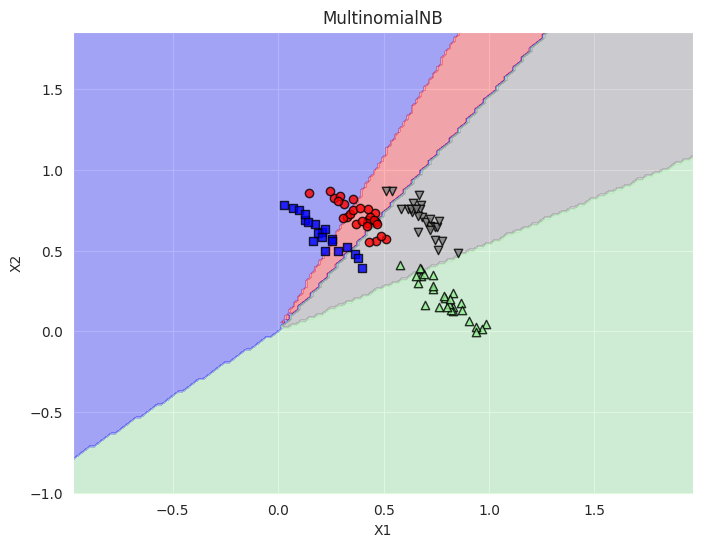

In [55]:
mnb = MultinomialNB(alpha=1, fit_prior=False)
mnb.fit(X_train_norm, y_train)

plot_decision_regions(X_test_norm, y_test, mnb, classifier_name="MultinomialNB")

### Метрики моделі naive_bayes.MultinomialNB

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.45      0.33      0.38        73
     Class 1       0.57      0.56      0.57        80
     Class 2       1.00      0.92      0.96        72
     Class 3       0.66      0.89      0.76        75

    accuracy                           0.67       300
   macro avg       0.67      0.68      0.67       300
weighted avg       0.67      0.67      0.66       300



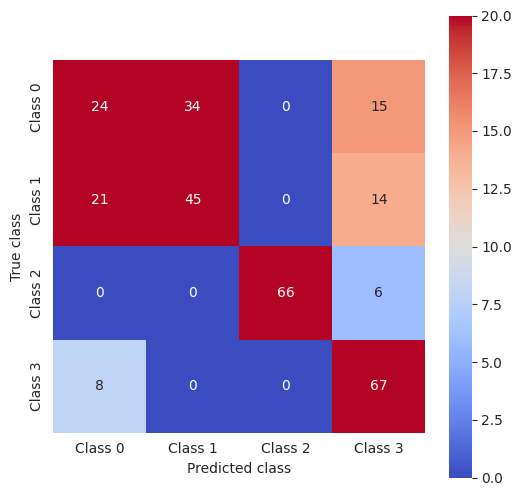

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.76      0.48      0.59        27
     Class 1       0.62      0.75      0.68        20
     Class 2       1.00      0.89      0.94        28
     Class 3       0.68      0.92      0.78        25

    accuracy                           0.76       100
   macro avg       0.77      0.76      0.75       100
weighted avg       0.78      0.76      0.75       100



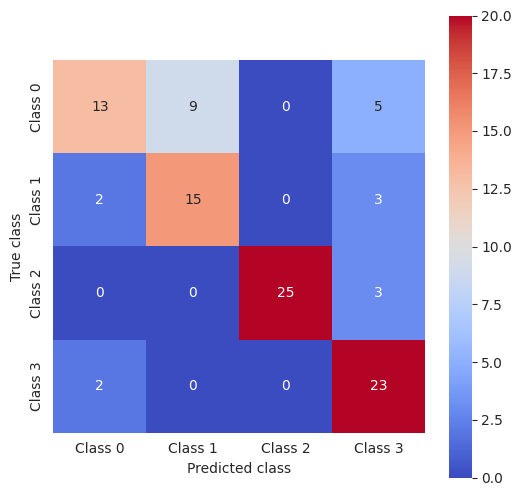

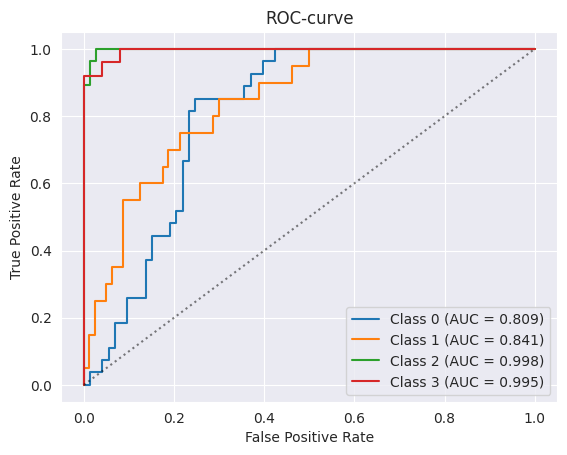

Macro-average ROC-AUC = 0.914


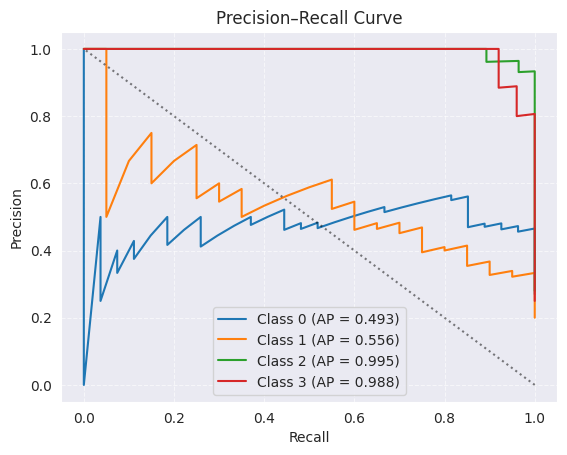

Macro-average AUC Precision–Recall = 0.758


In [56]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train_norm, y_train, mnb)

print("Evaluation metrics for test set:")
get_classifier_score(X_test_norm, y_test, mnb)
plot_roc_auc(X_test_norm, y_test, mnb)
plot_pr_curve(X_test_norm, y_test, mnb)

In [57]:
# Overfitting
train_acc = accuracy_score(y_train, mnb.predict(X_train_norm))
test_acc = accuracy_score(y_test, mnb.predict(X_test_norm))
print(train_acc - test_acc)

-0.08666666666666667


Отримані результати свідчать про **не дуже високу ефективність** класифікаційної моделі. \
Загальна точність становить **76%**, значеннями precision, recall та f1-score різняться для різних класів.

Confusion matrix показує не ідеальну діагональ та погані результати, але не дивлячись на це, \
ROC-криві для всіх класів мають AUC ****. Ці метрики свідчать про гіршу роздільну здатність моделі, ніж попередньої. \
Модель **"вгадує"** деякі класи, це також видно з графіка Precision-Recall.

Різниця між середніми оцінками на train і test становить приблизно **-0.087**, \
отже, модель здатна узагальнювати нові дані навіть краще за тренувальні і свідчить про **відсутність перенавчання**.

In [58]:
mnb.predict_proba(X_test_norm)

array([[0.23908978, 0.23124087, 0.24956371, 0.28010564],
       [0.29463248, 0.29835476, 0.15124776, 0.255765  ],
       [0.28281947, 0.28455139, 0.17393744, 0.2586917 ],
       [0.26649617, 0.26195884, 0.19445109, 0.27709391],
       [0.2508496 , 0.24417609, 0.22499971, 0.2799746 ],
       [0.27758794, 0.27777708, 0.18219861, 0.26243638],
       [0.19883188, 0.18930148, 0.34496767, 0.26689897],
       [0.22770746, 0.22016408, 0.2794755 , 0.27265296],
       [0.18466343, 0.17446317, 0.37863216, 0.26224124],
       [0.2678521 , 0.26318401, 0.19078361, 0.27818029],
       [0.2948885 , 0.29712589, 0.14703078, 0.26095482],
       [0.28962579, 0.2906483 , 0.15607932, 0.26364659],
       [0.19789647, 0.18805795, 0.34586366, 0.26818192],
       [0.2840746 , 0.28548594, 0.17010489, 0.26033457],
       [0.30454846, 0.30954616, 0.13158296, 0.25432242],
       [0.2102711 , 0.20196896, 0.32103097, 0.26672897],
       [0.28970489, 0.29223733, 0.15977275, 0.25828502],
       [0.26179078, 0.2583062 ,

## Dataset B

In [59]:
np.random.seed(0)
X = np.random.randn(300, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

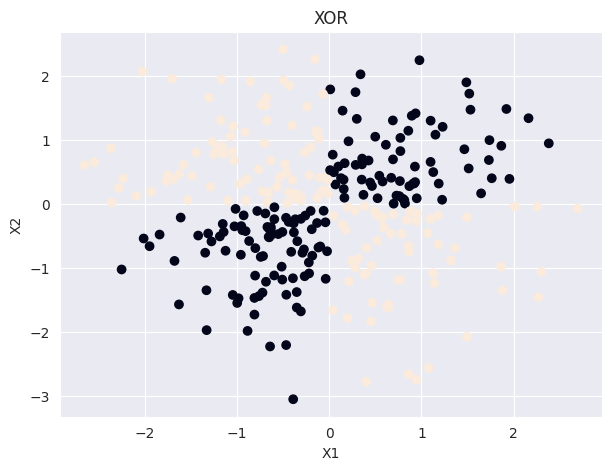

In [60]:
show_scatter(X, y, title="XOR")

### Розділ вибірки на навчальну і тестову та навчання моделі naive_bayes.GaussianNB

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

accuracy_score(y_test, gnb.predict(X_test))

0.5866666666666667

### Використання GridSearch для підбору гіперпараметрів для GaussianNB

In [62]:
param_grid_gnb = {
    "var_smoothing": [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}
grid_gnb = GridSearchCV(gnb, param_grid_gnb, cv=5)
grid_gnb.fit(X_train, y_train)

print(f"Best params:    {grid_gnb.best_params_}")
print(f"Train accuracy: {grid_gnb.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_gnb.best_estimator_.predict(X_test))}")

Best params:    {'var_smoothing': 1e-10}
Train accuracy: 0.5777777777777778
Test accuracy:  0.5866666666666667


### Перевірка роботи GaussianNB на тренувальних вибірках різного розміру

In [63]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, test_size=1-size, random_state=0
    )
    gnb.fit(X_sub, y_sub)

    acc = accuracy_score(y_test, gnb.predict(X_test))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 45 Accuracy = 0.52
Train size = 90 Accuracy = 0.56
Train size = 135 Accuracy = 0.56
Train size = 180 Accuracy = 0.6


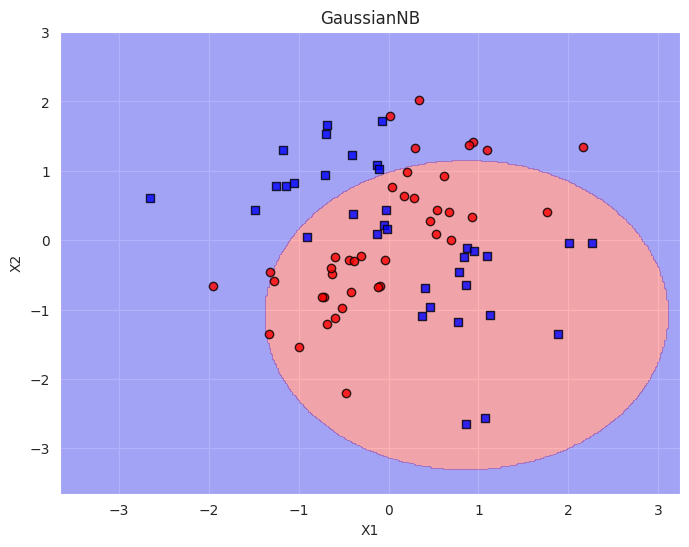

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

gnb = GaussianNB(var_smoothing=1e-10)
gnb.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, gnb, classifier_name="GaussianNB")

### Метрики моделі naive_bayes.GaussianNB

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.60      0.83      0.70       118
     Class 1       0.68      0.40      0.51       107

    accuracy                           0.63       225
   macro avg       0.64      0.62      0.60       225
weighted avg       0.64      0.63      0.61       225



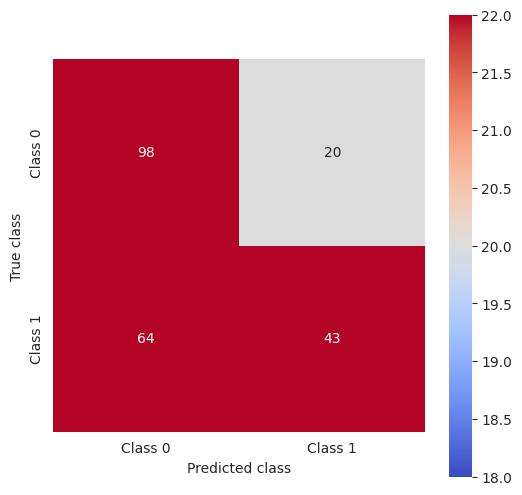

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.58      0.78      0.67        40
     Class 1       0.59      0.37      0.46        35

    accuracy                           0.59        75
   macro avg       0.59      0.57      0.56        75
weighted avg       0.59      0.59      0.57        75



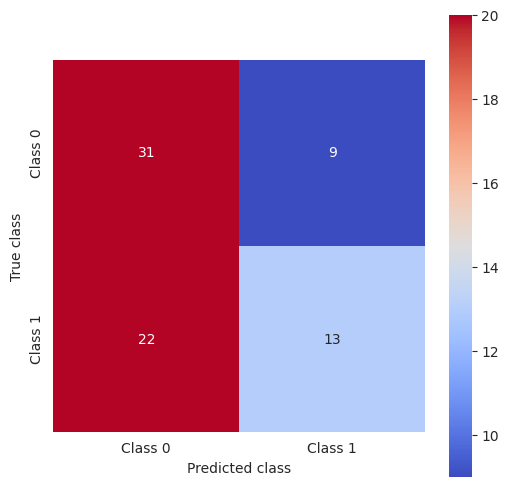

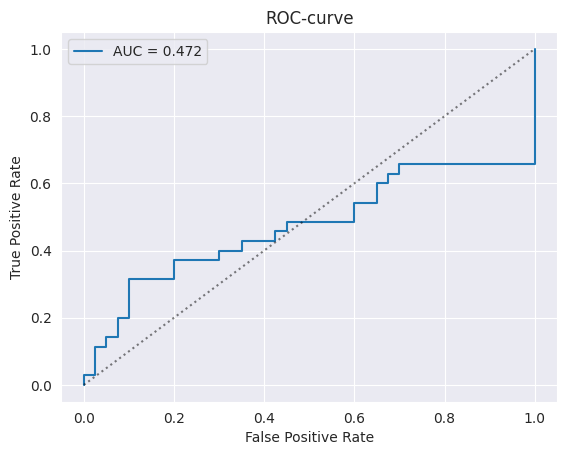

ROC–AUC = 0.472


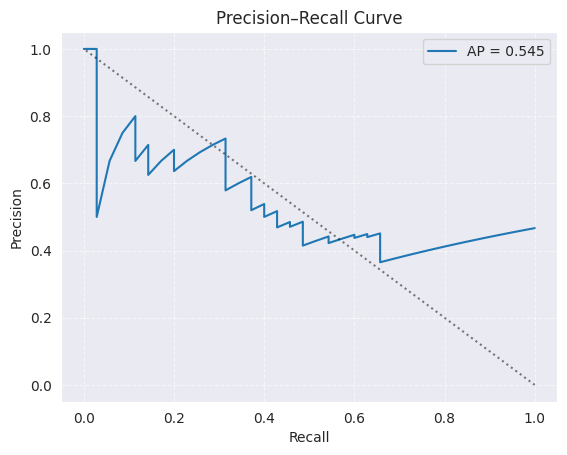

Average Precision (AUC PR) = 0.545


In [65]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, gnb)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, gnb)
plot_roc_auc(X_test, y_test, gnb)
plot_pr_curve(X_test, y_test, gnb)

In [66]:
# Overfitting
train_acc = accuracy_score(y_train, gnb.predict(X_train))
test_acc = accuracy_score(y_test, gnb.predict(X_test))
print(train_acc - test_acc)

0.040000000000000036


Отримані результати свідчать про **неефективність** класифікаційної моделі. \
Загальна точність становить **59%**, значеннями precision майже однакове для обох класів, recall та f1-score різняться для різних класів.

Confusion matrix, ROC-криві показують погані результати. Ці метрики свідчать, що модель має слабку здатність розпізнавати Class1 і\
випадкова у розділенні класів.

Різниця між середніми оцінками на train і test становить приблизно **0.04**, \
отже, модель здатна узагальнювати нові дані навіть краще за тренувальні і свідчить про **відсутність явного перенавчання**.

In [67]:
gnb.predict_proba(X_test)

array([[0.56517062, 0.43482938],
       [0.62351574, 0.37648426],
       [0.56708114, 0.43291886],
       [0.58449269, 0.41550731],
       [0.42369035, 0.57630965],
       [0.6264198 , 0.3735802 ],
       [0.56436812, 0.43563188],
       [0.56708278, 0.43291722],
       [0.52309366, 0.47690634],
       [0.56910957, 0.43089043],
       [0.59802451, 0.40197549],
       [0.51521936, 0.48478064],
       [0.6185884 , 0.3814116 ],
       [0.60488685, 0.39511315],
       [0.60644686, 0.39355314],
       [0.48229819, 0.51770181],
       [0.56294191, 0.43705809],
       [0.59093492, 0.40906508],
       [0.55619107, 0.44380893],
       [0.62214321, 0.37785679],
       [0.57165801, 0.42834199],
       [0.50286023, 0.49713977],
       [0.60084572, 0.39915428],
       [0.60901022, 0.39098978],
       [0.60070044, 0.39929956],
       [0.43487079, 0.56512921],
       [0.37332442, 0.62667558],
       [0.55112262, 0.44887738],
       [0.43396316, 0.56603684],
       [0.48993994, 0.51006006],
       [0.

## Навчання моделі naive_bayes.MultinomialNB

In [68]:
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_norm, y_train)

accuracy_score(y_test, mnb.predict(X_test_norm))

0.5333333333333333

### Використання GridSearch для підбору гіперпараметрів для MultinomialNB

In [69]:
param_grid_mnb = {
    "alpha": [1e-2, 1e-1, 1, 5, 10, 15],
    "fit_prior": [True, False]
}
grid_mnb = GridSearchCV(mnb, param_grid_mnb, cv=5)
grid_mnb.fit(X_train_norm, y_train)

print(f"Best params:    {grid_mnb.best_params_}")
print(f"Train accuracy: {grid_mnb.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mnb.best_estimator_.predict(X_test_norm))}")

Best params:    {'alpha': 0.01, 'fit_prior': False}
Train accuracy: 0.5911111111111111
Test accuracy:  0.52


### Перевірка роботи MultinomialNB на тренувальних вибірках різного розміру

In [70]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_norm, y_train, test_size=1-size, random_state=0
    )
    mnb.fit(X_sub, y_sub)

    acc = accuracy_score(y_test, mnb.predict(X_test_norm))
    print(f"Train size = {len(X_sub)} Accuracy = {acc}")

Train size = 45 Accuracy = 0.5333333333333333
Train size = 90 Accuracy = 0.5333333333333333
Train size = 135 Accuracy = 0.5333333333333333
Train size = 180 Accuracy = 0.5333333333333333


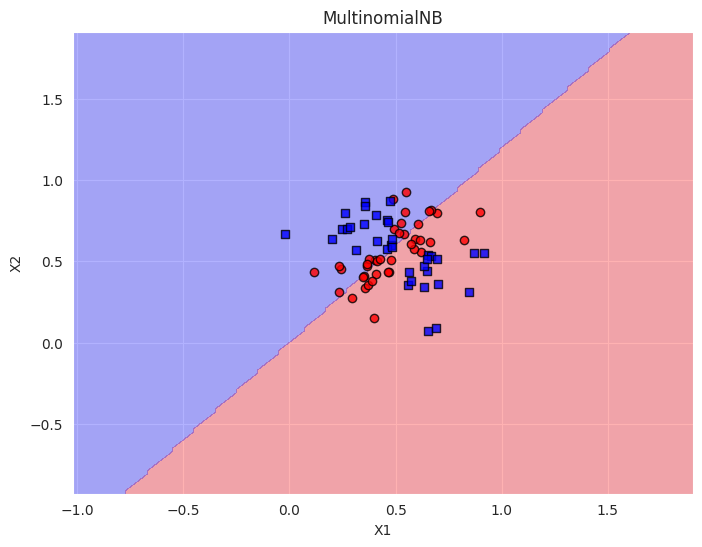

In [71]:
mnb = MultinomialNB(alpha=1e-2, fit_prior=False)
mnb.fit(X_train_norm, y_train)

plot_decision_regions(X_test_norm, y_test, mnb, classifier_name="MultinomialNB")

### Метрики моделі naive_bayes.MultinomialNB

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.61      0.58      0.59       118
     Class 1       0.56      0.58      0.57       107

    accuracy                           0.58       225
   macro avg       0.58      0.58      0.58       225
weighted avg       0.58      0.58      0.58       225



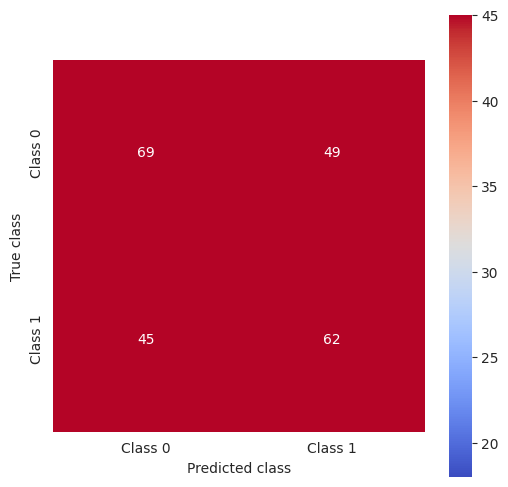

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.56      0.50      0.53        40
     Class 1       0.49      0.54      0.51        35

    accuracy                           0.52        75
   macro avg       0.52      0.52      0.52        75
weighted avg       0.52      0.52      0.52        75



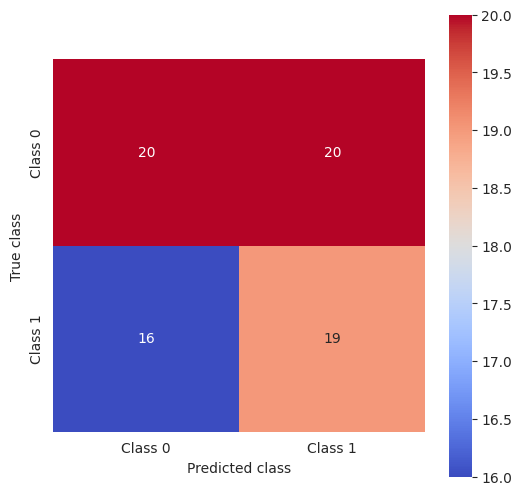

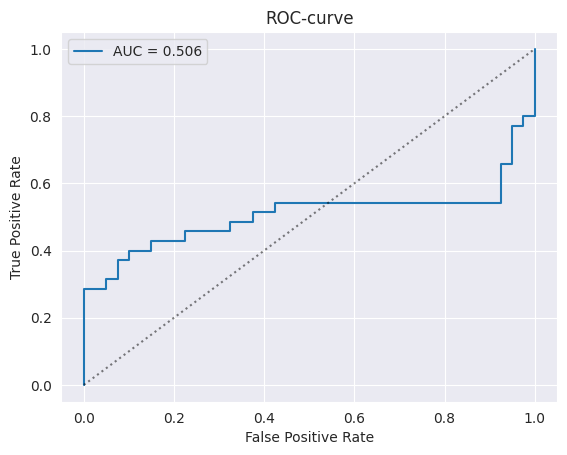

ROC–AUC = 0.506


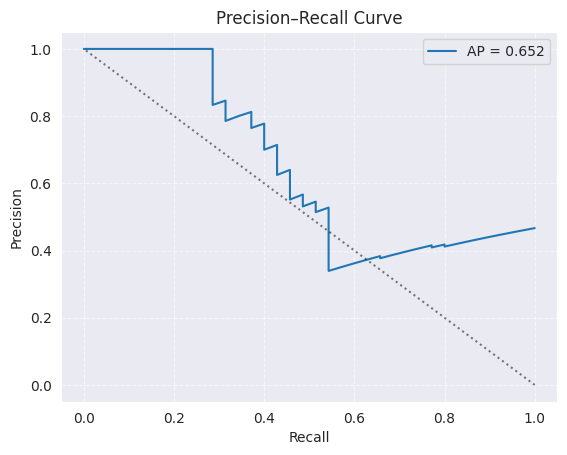

Average Precision (AUC PR) = 0.652


In [72]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train_norm, y_train, mnb)

print("Evaluation metrics for test set:")
get_classifier_score(X_test_norm, y_test, mnb)
plot_roc_auc(X_test_norm, y_test, mnb)
plot_pr_curve(X_test_norm, y_test, mnb)

In [73]:
# Overfitting
train_acc = accuracy_score(y_train, mnb.predict(X_train_norm))
test_acc = accuracy_score(y_test, mnb.predict(X_test_norm))
print(train_acc - test_acc)

0.06222222222222218


Отримані результати свідчать про **неефективність** класифікаційної моделі. \
Загальна точність становить **52%**, значеннями precision, recall та f1-score майже однакові для різних класів.

Confusion matrix показує погані результати, PR-AUC трохи краще. Ці метрики свідчать,\
що модель випадково класифікує дані.

Різниця між середніми оцінками на train і test становить приблизно **0.062**, \
отже, модель має **невелике перенавчання**, проте загальна точність вказує на недостатню здатність моделі розпізнавати класи.

In [74]:
mnb.predict_proba(X_test_norm)

array([[0.51280094, 0.48719906],
       [0.50611109, 0.49388891],
       [0.50160656, 0.49839344],
       [0.50118653, 0.49881347],
       [0.4926492 , 0.5073508 ],
       [0.50865136, 0.49134864],
       [0.49948559, 0.50051441],
       [0.50119064, 0.49880936],
       [0.49800613, 0.50199387],
       [0.49951993, 0.50048007],
       [0.50327917, 0.49672083],
       [0.49648889, 0.50351111],
       [0.50520599, 0.49479401],
       [0.50440694, 0.49559306],
       [0.5048341 , 0.4951659 ],
       [0.49627062, 0.50372938],
       [0.49941469, 0.50058531],
       [0.50227682, 0.49772318],
       [0.49873303, 0.50126697],
       [0.50561916, 0.49438084],
       [0.51336996, 0.48663004],
       [0.49937876, 0.50062124],
       [0.51266411, 0.48733589],
       [0.50571354, 0.49428646],
       [0.50220847, 0.49779153],
       [0.49309082, 0.50690918],
       [0.49508408, 0.50491592],
       [0.50579503, 0.49420497],
       [0.50489351, 0.49510649],
       [0.49655775, 0.50344225],
       [0.